In [ ]:
!pip install -q kaggle

import os
import shutil
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split, ConcatDataset
from torchvision import datasets, transforms

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print("PyTorch version:", torch.__version__)
print("GPU available:", torch.cuda.is_available())

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)

PyTorch version: 2.11.0+cu128
GPU available: True
Using: cuda


In [ ]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [4]:
import os

PROJECT_DIR = "/content/drive/MyDrive/ASL_Project"

KAGGLE_DIR = os.path.join(PROJECT_DIR, "kaggle_dataset")
MY_IMAGES_DIR = os.path.join(PROJECT_DIR, "my_images")

print("Kaggle dataset:", KAGGLE_DIR)
print("My images:", MY_IMAGES_DIR)

Kaggle dataset: /content/drive/MyDrive/ASL_Project/kaggle_dataset
My images: /content/drive/MyDrive/ASL_Project/my_images


In [ ]:
import os

print(os.listdir("/content/drive/MyDrive"))

['Colab Notebooks', 'Getting started.pdf', 'Scanned_20200407-1101.pdf', 'PROTEINS-BIOLOGY.docx', 'imgtopdf_generated_1706201359013.pdf', 'Medical Form.PDF', 'Medical Form.PDF.gdoc', 'Copy of Nathaniel · SlidesCarnival.gslides', '6fc06bdcc9484ef02ce358ba4a7da6b3.jpg', 'Coursework AO1.gdoc', 'English Assignment.gdoc', 'Untitled document (47).gdoc', 'Bio project work.gdoc', 'Untitled document (46).gdoc', 'Untitled document (45).gdoc', 'school list.gdoc', 'IGCSE  art exam ideas.gdoc', 'Untitled document (44).gdoc', 'Bio assignment.gdoc', 'Untitled document (43).gdoc', 'Untitled form.gform', 'Untitled document (42).gdoc', 'SCHOOL TIMETABLE.gdoc', 'art letter.gdoc', 'Untitled document (41).gdoc', 'Untitled document (40).gdoc', 'Untitled document (39).gdoc', 'links.gdoc', 'Untitled document (38).gdoc', 'w.gdoc', 'Art annotations.gdoc', 'IGCSE GEOGRAPHY NOTES 1.gdoc', 'IGCSE GEOGRAPHY NOTES 2.gdoc', 'PLATE TECTONICS (1).gslides', 'IGCSE GEOGRAPHY NOTES 3.gdoc', 'IGCSE GEOGRAPHY NOTES 4.gdoc', 

In [9]:
PROJECT_DIR = "/content/drive/MyDrive/ASL_Project"

print(os.listdir(PROJECT_DIR))

['Kaggle dataset', 'My images']


In [ ]:
classes = sorted(
    [
        folder
        for folder in os.listdir(KAGGLE_DIR)
        if os.path.isdir(os.path.join(KAGGLE_DIR, folder))
    ]
)

print("Classes:", classes)
print("Number of classes:", len(classes))

Classes: ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']
Number of classes: 26


In [12]:
PROJECT_DIR = "/content/drive/MyDrive/ASL_Project"

print("Contents of ASL_Project:")
print(os.listdir(PROJECT_DIR))

Contents of ASL_Project:
['Kaggle dataset', 'My images']


In [ ]:
from google.colab import drive
import os

# Mount Google Drive
drive.mount("/content/drive")

# Set the main project folder
PROJECT_DIR = "/content/drive/MyDrive/ASL_Project"

# Set dataset folders
KAGGLE_DIR = os.path.join(PROJECT_DIR, "kaggle_dataset")
MY_IMAGES_DIR = os.path.join(PROJECT_DIR, "my_images")

print("PROJECT_DIR:", PROJECT_DIR)
print("KAGGLE_DIR:", KAGGLE_DIR)
print("MY_IMAGES_DIR:", MY_IMAGES_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
PROJECT_DIR: /content/drive/MyDrive/ASL_Project
KAGGLE_DIR: /content/drive/MyDrive/ASL_Project/kaggle_dataset
MY_IMAGES_DIR: /content/drive/MyDrive/ASL_Project/my_images


In [15]:
print("Project contents:")
print(os.listdir(PROJECT_DIR))

Project contents:
['Kaggle dataset', 'My images']


In [16]:
print("Kaggle folder exists:", os.path.exists(KAGGLE_DIR))
print("My images folder exists:", os.path.exists(MY_IMAGES_DIR))

Kaggle folder exists: False
My images folder exists: False


In [17]:
print(os.listdir(PROJECT_DIR))

for item in os.listdir(PROJECT_DIR):
    full_path = os.path.join(PROJECT_DIR, item)
    print(item, "->", full_path)

['Kaggle dataset', 'My images']
Kaggle dataset -> /content/drive/MyDrive/ASL_Project/Kaggle dataset
My images -> /content/drive/MyDrive/ASL_Project/My images


In [18]:
print(os.listdir(PROJECT_DIR))
print("Kaggle folder exists:", os.path.exists(KAGGLE_DIR))
print("My images folder exists:", os.path.exists(MY_IMAGES_DIR))

['Kaggle dataset', 'My images']
Kaggle folder exists: False
My images folder exists: False


In [19]:
import os

PROJECT_DIR = "/content/drive/MyDrive/ASL_Project"

KAGGLE_DIR = os.path.join(PROJECT_DIR, "Kaggle dataset")
MY_IMAGES_DIR = os.path.join(PROJECT_DIR, "My images")

print("Kaggle folder exists:", os.path.exists(KAGGLE_DIR))
print("My images folder exists:", os.path.exists(MY_IMAGES_DIR))

Kaggle folder exists: True
My images folder exists: True


In [20]:
print("Kaggle dataset contents:")
print(os.listdir(KAGGLE_DIR))

Kaggle dataset contents:
['c', 'f', 'd', 'a', 'e', 'b', 'l', 'o', 'i', 'g', 'k', 'h', 'n', 'm', 'j', 'p', 'u', 'r', 't', 's', 'y', 'v', 'q', 'w', 'x', 'z']


In [ ]:
classes = sorted(
    [
        folder
        for folder in os.listdir(KAGGLE_DIR)
        if os.path.isdir(os.path.join(KAGGLE_DIR, folder))
    ]
)

print("Classes:", classes)
print("Number of classes:", len(classes))

Classes: ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']
Number of classes: 26


In [22]:
print("My images contents:")
print(os.listdir(MY_IMAGES_DIR))

My images contents:
['a', 'g', 'i', 'c', 'e', 'b', 'f', 'h', 'd', 'j', 'k', 'n', 'l', 'p', 'm', 'q', 't', 'r', 'v', 'w', 'z', 'y', 'u', 'x', 's', 'o']


In [23]:
for letter in sorted(os.listdir(MY_IMAGES_DIR)):
    folder_path = os.path.join(MY_IMAGES_DIR, letter)

    if os.path.isdir(folder_path):
        files = os.listdir(folder_path)
        print(letter, ":", len(files), "image(s)")

a : 1 image(s)
b : 1 image(s)
c : 1 image(s)
d : 1 image(s)
e : 1 image(s)
f : 1 image(s)
g : 1 image(s)
h : 1 image(s)
i : 1 image(s)
j : 1 image(s)
k : 1 image(s)
l : 1 image(s)
m : 1 image(s)
n : 1 image(s)
o : 1 image(s)
p : 1 image(s)
q : 1 image(s)
r : 1 image(s)
s : 1 image(s)
t : 1 image(s)
u : 1 image(s)
v : 1 image(s)
w : 1 image(s)
x : 1 image(s)
y : 1 image(s)
z : 1 image(s)


In [ ]:
classes = sorted(
    [
        folder
        for folder in os.listdir(KAGGLE_DIR)
        if os.path.isdir(os.path.join(KAGGLE_DIR, folder))
    ]
)

print("Classes:", classes)
print("Number of classes:", len(classes))

Classes: ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']
Number of classes: 26


In [ ]:
for class_name in classes:
    class_path = os.path.join(KAGGLE_DIR, class_name)

    images = [
        f
        for f in os.listdir(class_path)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    print(f"{class_name}: {len(images)}")

a: 55
b: 55
c: 55
d: 55
e: 55
f: 55
g: 55
h: 55
i: 55
j: 55
k: 55
l: 55
m: 55
n: 55
o: 55
p: 55
q: 55
r: 55
s: 55
t: 50
u: 55
v: 55
w: 55
x: 55
y: 55
z: 55


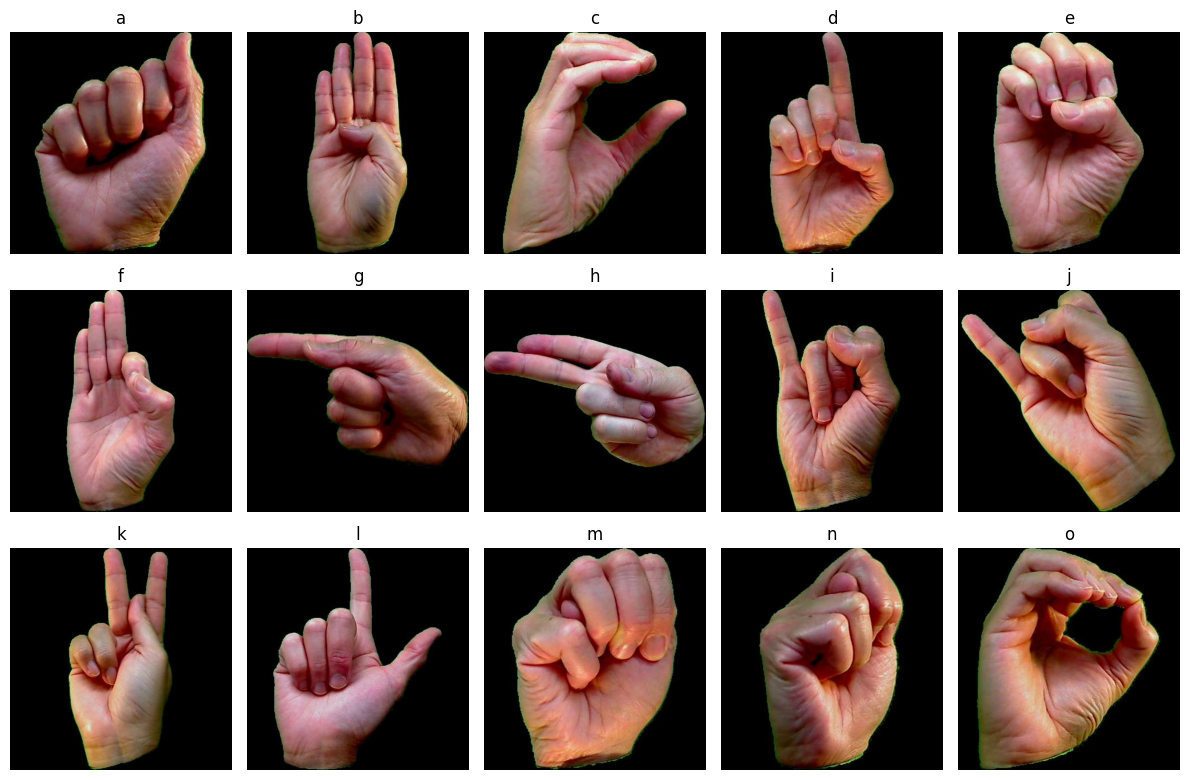

In [ ]:
import matplotlib.pyplot as plt
import os
import random
from PIL import Image

fig, axes = plt.subplots(3, 5, figsize=(12, 8))

for ax, class_name in zip(axes.flatten(), classes[:15]):
    class_path = os.path.join(KAGGLE_DIR, class_name)

    image_files = [
        f
        for f in os.listdir(class_path)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    image_path = os.path.join(class_path, random.choice(image_files))

    image = Image.open(image_path)

    ax.imshow(image, cmap="gray")
    ax.set_title(class_name)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader, random_split, ConcatDataset

from torchvision import datasets, transforms

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print("All libraries imported successfully!")

All libraries imported successfully!


In [ ]:
IMG_SIZE = 64

train_transform = transforms.Compose(
    [
        transforms.Grayscale(num_output_channels=1),
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.RandomRotation(10),
        transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5], std=[0.5]),
    ]
)

test_transform = transforms.Compose(
    [
        transforms.Grayscale(num_output_channels=1),
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5], std=[0.5]),
    ]
)

In [ ]:
full_dataset = datasets.ImageFolder(KAGGLE_DIR, transform=train_transform)

print("Total images:", len(full_dataset))
print("Classes:", full_dataset.classes)
print("Class mapping:", full_dataset.class_to_idx)

Total images: 1425
Classes: ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']
Class mapping: {'a': 0, 'b': 1, 'c': 2, 'd': 3, 'e': 4, 'f': 5, 'g': 6, 'h': 7, 'i': 8, 'j': 9, 'k': 10, 'l': 11, 'm': 12, 'n': 13, 'o': 14, 'p': 15, 'q': 16, 'r': 17, 's': 18, 't': 19, 'u': 20, 'v': 21, 'w': 22, 'x': 23, 'y': 24, 'z': 25}


In [ ]:
my_dataset = datasets.ImageFolder(MY_IMAGES_DIR, transform=train_transform)

print("My images:", len(my_dataset))
print("Classes:", my_dataset.classes)

My images: 26
Classes: ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']


In [34]:
print("Kaggle:", full_dataset.class_to_idx)
print("Mine:", my_dataset.class_to_idx)

Kaggle: {'a': 0, 'b': 1, 'c': 2, 'd': 3, 'e': 4, 'f': 5, 'g': 6, 'h': 7, 'i': 8, 'j': 9, 'k': 10, 'l': 11, 'm': 12, 'n': 13, 'o': 14, 'p': 15, 'q': 16, 'r': 17, 's': 18, 't': 19, 'u': 20, 'v': 21, 'w': 22, 'x': 23, 'y': 24, 'z': 25}
Mine: {'a': 0, 'b': 1, 'c': 2, 'd': 3, 'e': 4, 'f': 5, 'g': 6, 'h': 7, 'i': 8, 'j': 9, 'k': 10, 'l': 11, 'm': 12, 'n': 13, 'o': 14, 'p': 15, 'q': 16, 'r': 17, 's': 18, 't': 19, 'u': 20, 'v': 21, 'w': 22, 'x': 23, 'y': 24, 'z': 25}


In [ ]:
combined_dataset = ConcatDataset([full_dataset, my_dataset])

print("Combined dataset size:", len(combined_dataset))

Combined dataset size: 1451


In [ ]:
dataset_size = len(combined_dataset)

train_size = int(0.70 * dataset_size)
val_size = int(0.15 * dataset_size)
test_size = dataset_size - train_size - val_size

generator = torch.Generator().manual_seed(42)

train_dataset, val_dataset, test_dataset = random_split(
    combined_dataset, [train_size, val_size, test_size], generator=generator
)

print("Training:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Testing:", len(test_dataset))

Training: 1015
Validation: 217
Testing: 219


In [ ]:
BATCH_SIZE = 64

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True
)

val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True
)

test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True
)

In [38]:
images, labels = next(iter(train_loader))

print("Image shape:", images.shape)
print("Label shape:", labels.shape)

Image shape: torch.Size([64, 1, 64, 64])
Label shape: torch.Size([64])


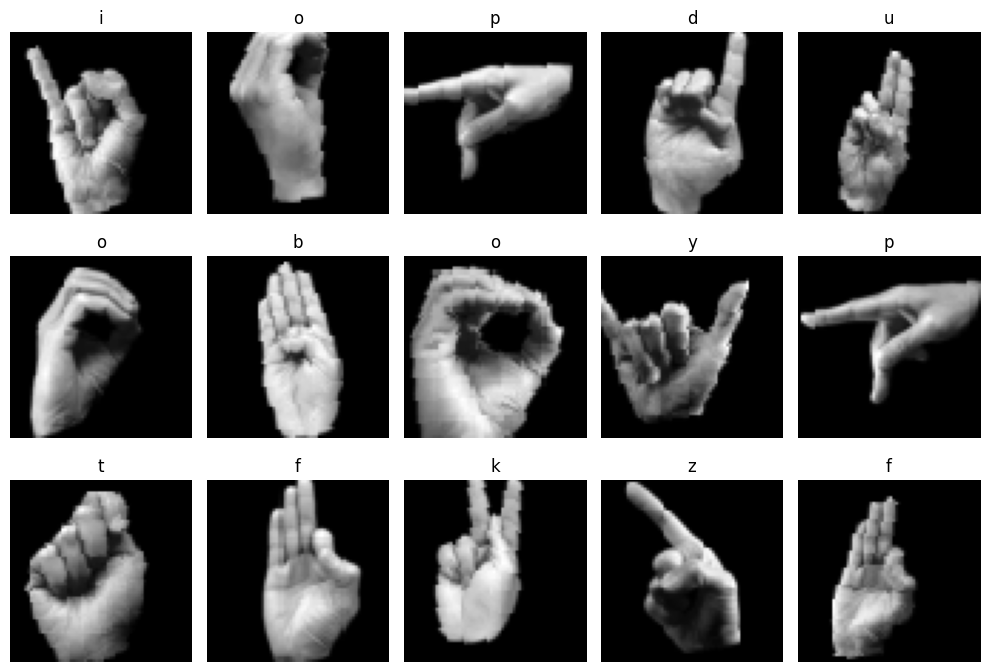

In [39]:
fig, axes = plt.subplots(3, 5, figsize=(10, 7))

for i, ax in enumerate(axes.flatten()):
    image = images[i].squeeze().numpy()

    # Undo normalization
    image = image * 0.5 + 0.5

    ax.imshow(image, cmap="gray")
    ax.set_title(full_dataset.classes[labels[i]])
    ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
class ASLCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.features = nn.Sequential(
            # 64x64 -> 32x32
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            # 32x32 -> 16x16
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            # 16x16 -> 8x8
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),
            # 8x8 -> 4x4
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 4 * 4, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [42]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

Using device: cuda


In [43]:
num_classes = len(full_dataset.classes)

model = ASLCNN(num_classes=num_classes)

model = model.to(device)

print(model)

ASLCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  

In [ ]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", patience=3, factor=0.5
)

In [ ]:
def train_one_epoch(model, loader, criterion, optimizer):

    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item() * images.size(0)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy

In [ ]:
def evaluate(model, loader, criterion):

    model.eval()

    running_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy

In [ ]:
NUM_EPOCHS = 20

history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

best_val_loss = float("inf")

for epoch in range(NUM_EPOCHS):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer)

    val_loss, val_acc = evaluate(model, val_loader, criterion)

    scheduler.step(val_loss)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    print(
        f"Epoch [{epoch + 1}/{NUM_EPOCHS}] "
        f"Train Loss: {train_loss:.4f} "
        f"Train Acc: {train_acc:.4f} "
        f"Val Loss: {val_loss:.4f} "
        f"Val Acc: {val_acc:.4f}"
    )

    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss

        torch.save(
            model.state_dict(), "/content/drive/MyDrive/ASL_Project/best_asl_model.pth"
        )

        print("  ✓ Best model saved")

Epoch [1/20] Train Loss: 3.2420 Train Acc: 0.1232 Val Loss: 3.2160 Val Acc: 0.0829
  ✓ Best model saved
Epoch [2/20] Train Loss: 2.4199 Train Acc: 0.2670 Val Loss: 2.9320 Val Acc: 0.1613
  ✓ Best model saved
Epoch [3/20] Train Loss: 1.8435 Train Acc: 0.4049 Val Loss: 1.7016 Val Acc: 0.4516
  ✓ Best model saved
Epoch [4/20] Train Loss: 1.4357 Train Acc: 0.5172 Val Loss: 1.3688 Val Acc: 0.5300
  ✓ Best model saved
Epoch [5/20] Train Loss: 1.1735 Train Acc: 0.6030 Val Loss: 0.8285 Val Acc: 0.7373
  ✓ Best model saved
Epoch [6/20] Train Loss: 0.9743 Train Acc: 0.6591 Val Loss: 0.7948 Val Acc: 0.7696
  ✓ Best model saved
Epoch [7/20] Train Loss: 0.8634 Train Acc: 0.7094 Val Loss: 0.5543 Val Acc: 0.8341
  ✓ Best model saved
Epoch [8/20] Train Loss: 0.7439 Train Acc: 0.7527 Val Loss: 0.5656 Val Acc: 0.7972
Epoch [9/20] Train Loss: 0.6799 Train Acc: 0.7635 Val Loss: 0.5838 Val Acc: 0.7742
Epoch [10/20] Train Loss: 0.6009 Train Acc: 0.8167 Val Loss: 0.5181 Val Acc: 0.8065
  ✓ Best model saved
E

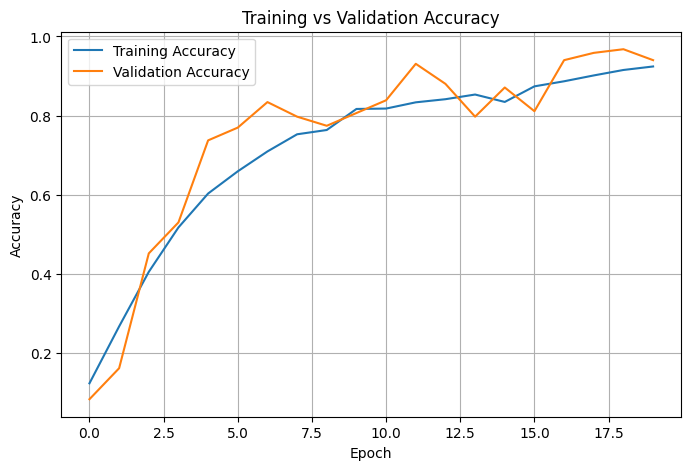

In [48]:
plt.figure(figsize=(8, 5))

plt.plot(history["train_acc"], label="Training Accuracy")
plt.plot(history["val_acc"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")

plt.legend()
plt.grid()

plt.show()

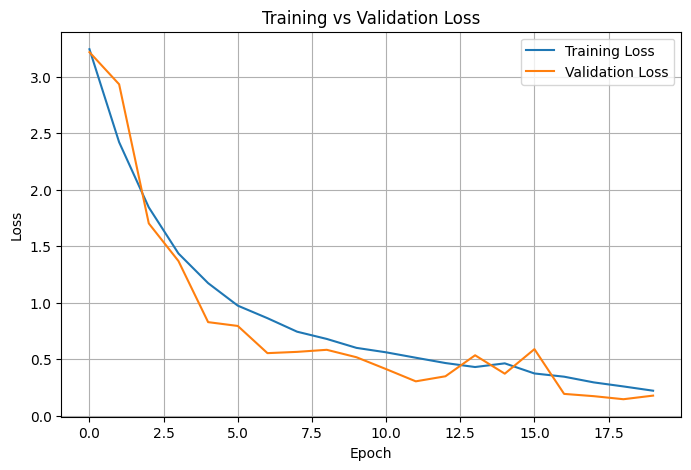

In [49]:
plt.figure(figsize=(8, 5))

plt.plot(history["train_loss"], label="Training Loss")
plt.plot(history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")

plt.legend()
plt.grid()

plt.show()

In [ ]:
model.load_state_dict(
    torch.load(
        "/content/drive/MyDrive/ASL_Project/best_asl_model.pth", map_location=device
    )
)

model.to(device)

print("Best model loaded.")

Best model loaded.


In [ ]:
model.eval()

all_predictions = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        outputs = model(images)

        predictions = torch.argmax(outputs, dim=1)

        all_predictions.extend(predictions.cpu().numpy())

        all_labels.extend(labels.numpy())

test_accuracy = accuracy_score(all_labels, all_predictions)

print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

Test Accuracy: 94.06%


In [ ]:
print(
    classification_report(
        all_labels, all_predictions, target_names=full_dataset.classes
    )
)

              precision    recall  f1-score   support

           a       0.86      0.86      0.86         7
           b       1.00      1.00      1.00         4
           c       1.00      0.91      0.95        11
           d       1.00      0.90      0.95        10
           e       1.00      0.91      0.95        11
           f       1.00      1.00      1.00        10
           g       1.00      0.88      0.93         8
           h       0.91      1.00      0.95        10
           i       1.00      1.00      1.00         7
           j       1.00      1.00      1.00        17
           k       1.00      0.88      0.93         8
           l       1.00      1.00      1.00        12
           m       0.80      0.89      0.84         9
           n       0.83      0.62      0.71         8
           o       0.86      1.00      0.92         6
           p       1.00      1.00      1.00         5
           q       1.00      1.00      1.00         8
           r       1.00    

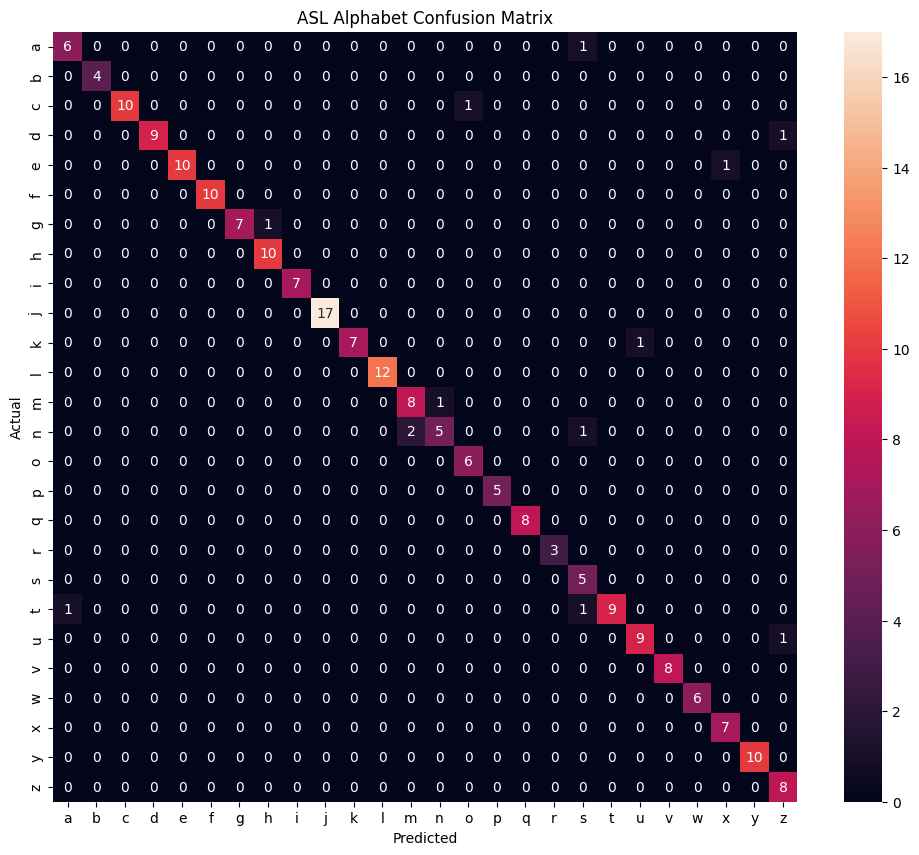

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(all_labels, all_predictions)

plt.figure(figsize=(12, 10))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=full_dataset.classes,
    yticklabels=full_dataset.classes,
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("ASL Alphabet Confusion Matrix")

plt.show()

In [55]:
from google.colab import files

uploaded = files.upload()

Saving d.jpg to d.jpg


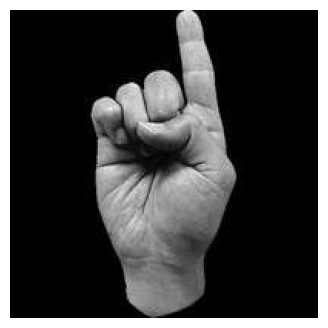

In [57]:
image_name = list(uploaded.keys())[0]

image = Image.open(image_name)

plt.figure(figsize=(4, 4))
plt.imshow(image, cmap="gray")
plt.axis("off")
plt.show()

In [58]:
from google.colab import files

uploaded = files.upload()

Saving hand4_g_bot_seg_1_cropped.jpeg to hand4_g_bot_seg_1_cropped.jpeg


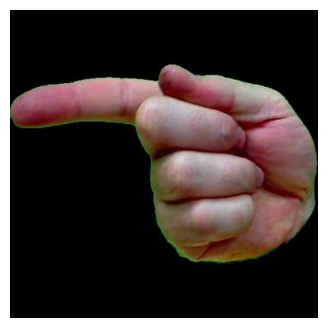

In [59]:
image_name = list(uploaded.keys())[0]

image = Image.open(image_name)

plt.figure(figsize=(4, 4))
plt.imshow(image, cmap="gray")
plt.axis("off")
plt.show()

In [ ]:
image_tensor = test_transform(image)

image_tensor = image_tensor.unsqueeze(0)

image_tensor = image_tensor.to(device)

model.eval()

with torch.no_grad():
    output = model(image_tensor)

    probabilities = torch.softmax(output, dim=1)

    confidence, prediction = torch.max(probabilities, dim=1)

predicted_class = full_dataset.classes[prediction.item()]

print("Predicted letter:", predicted_class)
print(f"Confidence: {confidence.item() * 100:.2f}%")

Predicted letter: g
Confidence: 85.27%


In [ ]:
top_probs, top_indices = torch.topk(probabilities, k=3)

print("Top predictions:")

for prob, index in zip(top_probs[0], top_indices[0]):
    letter = full_dataset.classes[index.item()]

    print(f"{letter}: {prob.item() * 100:.2f}%")

Top predictions:
g: 85.27%
h: 14.56%
p: 0.12%


In [62]:
from google.colab import files

uploaded = files.upload()

Saving WhatsApp Image 2026-08-12 at 3.04.59 PM.jpeg to WhatsApp Image 2026-08-12 at 3.04.59 PM.jpeg


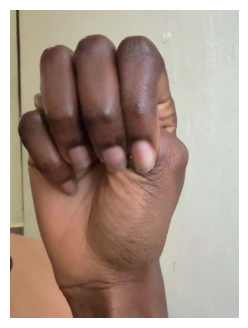

In [63]:
image_name = list(uploaded.keys())[0]

image = Image.open(image_name)

plt.figure(figsize=(4, 4))
plt.imshow(image, cmap="gray")
plt.axis("off")
plt.show()

In [ ]:
image_tensor = test_transform(image)

image_tensor = image_tensor.unsqueeze(0)

image_tensor = image_tensor.to(device)

model.eval()

with torch.no_grad():
    output = model(image_tensor)

    probabilities = torch.softmax(output, dim=1)

    confidence, prediction = torch.max(probabilities, dim=1)

predicted_class = full_dataset.classes[prediction.item()]

print("Predicted letter:", predicted_class)
print(f"Confidence: {confidence.item() * 100:.2f}%")

Predicted letter: m
Confidence: 85.07%
